<a href="https://colab.research.google.com/github/YenugulaRamya/my-colab-projects/blob/main/max_cut_for_qaoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Instructions for Google Colab. You can ignore this cell if you have CUDA-Q
## set up locally with all required files on your system.
## Uncomment the lines below and execute this cell to install dependencies.

!pip install cudaq cudaq-solvers -q
## If cudaq-solvers raises a libgfortran error on Colab, also run:
!apt-get install -y libgfortran5

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgfortran5 is already the newest version (12.3.0-1ubuntu1~22.04.3).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
import os
import re
import sys
from typing import List

# Scientific computing
import numpy as np

# Visualization and graph utilities
import matplotlib.pyplot as plt
import networkx as nx

# CUDA-Q
import cudaq
from cudaq import spin
import cudaq_solvers as solvers

# Notebook display helpers
from IPython.display import HTML, display

The graph has 7 nodes and 8 edges.


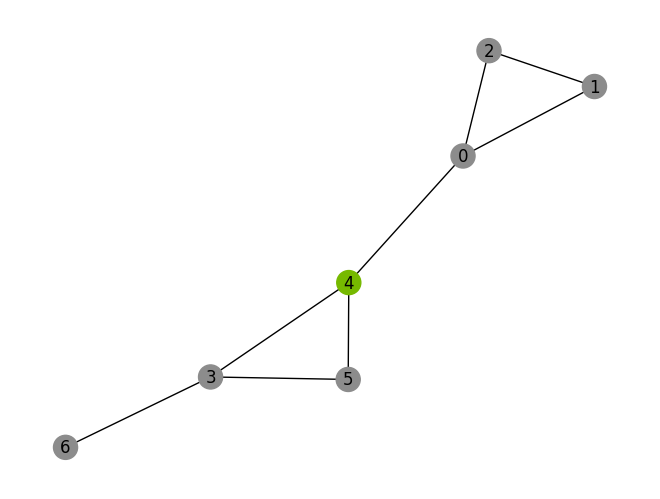

In [ ]:
edgeList = [(0,1),(1,2),(2,0),(0,4),(4,5),(5,3),(4,3), (3,6)]
sampleGraph =nx.from_edgelist(edgeList)

nx.set_node_attributes(sampleGraph, values = 0, name = 'color')
sampleGraph.nodes[4]['color'] = 1

node_List : List[int] = list(sampleGraph.nodes())
edges_in_graph = list(sampleGraph.edges())
print('The graph has',sampleGraph.number_of_nodes(),'nodes and', sampleGraph.number_of_edges(), 'edges.')

gray ='#8C8C8C'
green ='#76B900'
color_map = [gray if sampleGraph.nodes[u]['color']==0 else green for u in sampleGraph]

pos = nx.spring_layout(sampleGraph, seed=311)
nx.draw(sampleGraph, with_labels=True, pos = pos, node_color=color_map)
plt.show()

In [ ]:
sampleGraph.nodes[4]['color'] = 0

In [ ]:
max_cut_value = 0
max_cut_edges = []
subsets = [[]]
for u in sampleGraph.nodes():
    subsets = subsets + [s + [u] for s in subsets]

for subset in subsets:
    cut_val = sum(1 for u, v in sampleGraph.edges()
                  if (u in subset) != (v in subset))
    if cut_val > max_cut_value:
        max_cut_value = cut_val
        group0 = subset

group1 = [u for u in sampleGraph.nodes() if u not in group0]

print(f"Exact max cut value: {max_cut_value}")
print(f"Groups: Group 0={group0}, Group 1={group1}")
print(f"\nWe'll use this as a benchmark for the QAOA result.")

Exact max cut value: 6
Groups: Group 0=[0, 3], Group 1=[1, 2, 4, 5, 6]

We'll use this as a benchmark for the QAOA result.


In [ ]:
# Born's Rule Interactive Widget
scale = 0.8
content_height = 1050
visible_height = int(content_height * scale)

HTML(f'''<div style="overflow:hidden; height:{visible_height}px;">
  <iframe src="https://nvidia.github.io/cuda-q-academic/quick-start-to-quantum/interactive_widget/borns-rule-widget-sampling.html"
    style="width:{int(100/scale)}%; height:{content_height}px; border:none;
           transform:scale({scale}); transform-origin:top left;">
  </iframe>
</div>''')

In [ ]:
# QAOA Max Cut Explorer applet
scale = 0.8  # Change this to zoom: 0.7 = more zoomed out, 1.0 = full size
content_height = 1250  # Full height of the widget content in px
visible_height = int(content_height * scale)

HTML(f'''<div style="overflow:hidden; height:{visible_height}px;">
  <iframe src="https://nvidia.github.io/cuda-q-academic/interactive_widgets/triangle-qaoa.html"
    style="width:{int(100/scale)}%; height:{content_height}px; border:none;
           transform:scale({scale}); transform-origin:top left;">
  </iframe>
</div>''')

In [ ]:
H = solvers.get_maxcut_hamiltonian(sampleGraph)

print("Max Cut Hamiltonian for sampleGraph:")
print(H)

Max Cut Hamiltonian for sampleGraph:
(-4+0i) + (0.5+0i) * Z3Z4 + (0.5+0i) * Z3Z5 + (0.5+0i) * Z3Z6 + (0.5+0i) * Z4Z5 + (0.5+0i) * Z1Z2 + (0.5+0i) * Z0Z1 + (0.5+0i) * Z0Z2 + (0.5+0i) * Z0Z4


In [ ]:
def qaoa_for_graph(G, layer_count, seed):
    """Run QAOA to approximate the max cut of a graph using cudaq_solvers.

    Parameters
    ----------
    G: networkX graph
        Problem graph whose max cut we aim to approximate
    layer_count : int
        Number of layers in the QAOA circuit
    seed : int
        Random seed for reproducibility of results

    Returns
    -------
    str
        Binary string representing the most probable coloring found by QAOA
    """
    mapping = {node: i for i, node in enumerate(sorted(G.nodes()))}
    G_mapped = nx.relabel_nodes(G, mapping)

    H = solvers.get_maxcut_hamiltonian(G_mapped)

    parameter_count = 2 * layer_count
    np.random.seed(seed)
    cudaq.set_random_seed(seed)

    initial_parameters = np.random.uniform(-np.pi, np.pi, parameter_count)

    opt_value, opt_params, opt_config = solvers.qaoa(
        H,
        layer_count,
        initial_parameters,
        optimizer="cobyla"
    )

    print("Optimal parameters = ", opt_params)
    print("Most probable outcome = ", opt_config.most_probable())

    return str(opt_config.most_probable())

In [ ]:
# Run this notebook on CPU by default using 'qpp-cpu'; use only explicitly marked QPU sections on real hardware.
# Since this quantum circuit is not too large, we can run it on a CPU.  For a full list of available targets, see:
# https://nvidia.github.io/cuda-quantum/latest/using/backends/backends.html
cudaq.set_target('qpp-cpu')

result = qaoa_for_graph(sampleGraph, layer_count=1, seed=110)

graphColors = [int(i) for i in result]
nodes = sorted(list(nx.nodes(sampleGraph)))

qaoa_cut_value = 0
cut_edges = []

for u, v in sampleGraph.edges():
    indexu = nodes.index(u)
    indexv = nodes.index(v)
    if graphColors[indexu] != graphColors[indexv]:
        qaoa_cut_value += 1
        cut_edges.append((u, v))

group0 = []
group1 = []
for u in sampleGraph.nodes():
    indexu = nodes.index(u)
    if graphColors[indexu] == 0:
        group0.append(u)
        sampleGraph.nodes[u]['color'] = 0
    else:
        group1.append(u)
        sampleGraph.nodes[u]['color'] = 1

print(f'\nQAOA (p=1) cut value: {qaoa_cut_value}  (optimal = {max_cut_value})')
print(f'Groups: Group 0={group0}, Group 1={group1}')
if qaoa_cut_value == max_cut_value:
    print('QAOA found the optimal max cut!')
else:
    print(f'QAOA found a suboptimal cut. With p=1, this can happen — try increasing p for more reliable results.')

Optimal parameters =  [-2.4899541730789516, 2.0772866111688355]
Most probable outcome =  0000111

QAOA (p=1) cut value: 4  (optimal = 6)
Groups: Group 0=[0, 1, 2, 3], Group 1=[4, 5, 6]
QAOA found a suboptimal cut. With p=1, this can happen — try increasing p for more reliable results.


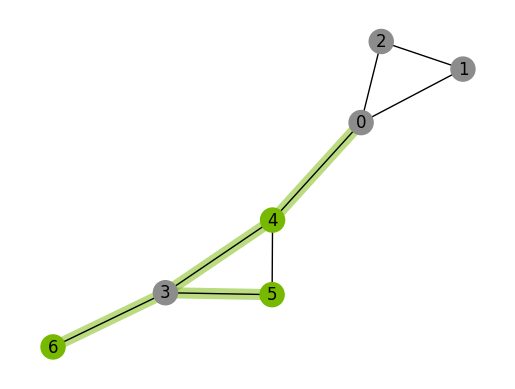

In [ ]:
max_cut_color_map = [gray if sampleGraph.nodes[u]['color']==0 else green for u in sampleGraph]

nx.draw_networkx_edges(
    sampleGraph,
    pos,
    edgelist=cut_edges,
    width=8,
    alpha=0.5,
    edge_color=green,
)
nx.draw(sampleGraph, with_labels=True, pos = pos, node_color=max_cut_color_map)
plt.show()

In [ ]:
@cudaq.kernel
def kernel_qaoa_p1(qubits_num: int,
                    ham_word: list[cudaq.pauli_word],
                    ham_coef: list[complex],
                    thetas: list[float],
                    num_layers: int):
    qubits = cudaq.qvector(qubits_num)
    h(qubits)
    for p in range(num_layers):
        for i in range(len(ham_coef)):
            exp_pauli(thetas[2 * p] * ham_coef[i].real, qubits, ham_word[i])
        for j in range(qubits_num):
            rx(2.0 * thetas[2 * p + 1], qubits[j])

# Hamiltonian terms in Pauli word format
ham_word_hw = ['ZZIIIII', 'IIIIIII', 'IIIIIII', 'ZIZIIII', 'IIIIIII',
               'ZIIIZII', 'IIIIIII', 'IZZIIII', 'IIIIIII', 'IIIIZZI',
               'IIIIIII', 'IIIZZII', 'IIIIIII', 'IIIZIZI', 'IIIIIII',
               'IIIZIIZ', 'IIIIIII']
ham_coef_hw = [(0.5+0j), (-0.5-0j), 0j, (0.5+0j), (-0.5-0j),
               (0.5+0j), (-0.5-0j), (0.5+0j), (-0.5-0j), (0.5+0j),
               (-0.5-0j), (0.5+0j), (-0.5-0j), (0.5+0j), (-0.5-0j),
               (0.5+0j), (-0.5-0j)]

n_q = sampleGraph.number_of_nodes()
edges_in_graph = list(sampleGraph.edges())
node_idx_hw = {n: i for i, n in enumerate(sorted(sampleGraph.nodes()))}

# Re-extract the optimized p=1 parameters (same optimization as above)
mapping_hw = {node: i for i, node in enumerate(sorted(sampleGraph.nodes()))}
G_mapped_hw = nx.relabel_nodes(sampleGraph, mapping_hw)
H_hw = solvers.get_maxcut_hamiltonian(G_mapped_hw)

np.random.seed(110)
cudaq.set_random_seed(110)
init_params_hw = np.random.uniform(-np.pi, np.pi, 2)
_, opt_params_p1, _ = solvers.qaoa(H_hw, 1, init_params_hw, optimizer="cobyla")

print(f"Optimized p=1 parameters: \u03b3 = {opt_params_p1[0]:.6f},  \u03b2 = {opt_params_p1[1]:.6f}")

Optimized p=1 parameters: γ = -2.489954,  β = 2.077287


In [ ]:
shots = 5000

def cut_value_from_bitstring(bitstring):
    """Compute the cut value for a given bitstring coloring."""
    return sum(1 for u, v in edges_in_graph
               if bitstring[node_idx_hw[u]] != bitstring[node_idx_hw[v]])

# ══ Sample in simulation (reference) ════════════════════════════════════════
cudaq.set_target('qpp-cpu')
counts_sim = cudaq.sample(
    kernel_qaoa_p1, n_q, ham_word_hw, ham_coef_hw,
    list(opt_params_p1), 1, shots_count=shots
)

sim_bs = counts_sim.most_probable()
sim_cut = cut_value_from_bitstring(sim_bs)
print(f"Simulation  \u2014 most probable: {sim_bs}  (cut = {sim_cut} / {max_cut_value})")

Simulation  — most probable: 1011101  (cut = 4 / 6)


In [ ]:
scale = 0.8  # Change this to zoom: 0.7 = more zoomed out, 1.0 = full size
content_height = 1250  # Full height of the widget content in px
visible_height = int(content_height * scale)

HTML(f'''<div style="overflow:hidden; height:{visible_height}px;">
  <iframe src="https://nvidia.github.io/cuda-q-academic/interactive_widgets/qaoa-landscape.html"
    style="width:{int(100/scale)}%; height:{content_height}px; border:none;
           transform:scale({scale}); transform-origin:top left;">
  </iframe>
</div>''')

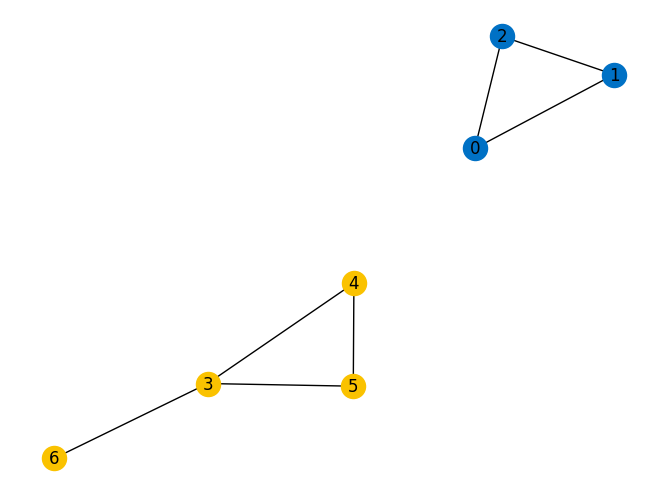

In [ ]:
blue = '#0071C5'
yellow = '#FAC200'

subGraph_dictionary = {}
subgraphColors={}
subGraph_names=[]
for i in range(2):
    name='sampleSubgraph'+str(i)
    subGraph_names.append(name)
    if i ==0:
        subgraphColors[name] = blue
    else:
        subgraphColors[name] = yellow

nodes0 = [0,1,2]
subGraph_dictionary[subGraph_names[0]] = nx.subgraph(sampleGraph, nodes0)

nodes1 = [3,4,5,6]
subGraph_dictionary[subGraph_names[1]] = nx.subgraph(sampleGraph, nodes1)

for key in subGraph_dictionary:
    nx.draw(subGraph_dictionary[key], pos=pos, with_labels=True, node_color = subgraphColors[key])
plt.show()

In [ ]:
cudaq.set_target('qpp-cpu')

layer_count = 1

# Set random seed for reproducibility
seed = {}
i = 4
for key in subGraph_dictionary:
    seed[key] = i
    i += 13

results = {}

for key in subGraph_dictionary:
    print(f'\nRunning solver for {key}:')
    G = subGraph_dictionary[key]
    results[key] = qaoa_for_graph(G, layer_count, seed[key])


Running solver for sampleSubgraph0:
Optimal parameters =  [2.5260829154391766, 0.3077202545841778]
Most probable outcome =  100

Running solver for sampleSubgraph1:
Optimal parameters =  [-0.6528970661725311, 0.32934783619149754]
Most probable outcome =  0101


The cut value for this partition is 5.
This is less than the optimal value of 6 that we found earlier.
We have not optimally combined the subgraph max cut solutions into a
solution for sampleGraph. We can be more careful about how we merge
together the subgraph solutions to generate a cut of the original graph.
We'll explore this in the next section.


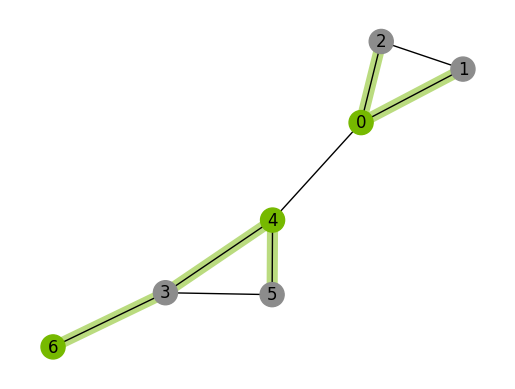

In [ ]:
for key in subGraph_dictionary:
    graphColors=[int(i) for i in results[key]]
    nodes = sorted(list(nx.nodes(subGraph_dictionary[key])))

    for u in sampleGraph.nodes():
        if u in nodes:
            indexu = nodes.index(u)
            if graphColors[indexu] == 0:
                sampleGraph.nodes[u]['color']= 0
            else:
                sampleGraph.nodes[u]['color']= 1

cut_edges =[]
for u, v in sampleGraph.edges():
    if sampleGraph.nodes[u]['color']!= sampleGraph.nodes[v]['color']:
        cut_edges+=[(u,v)]

print(f'The cut value for this partition is {len(cut_edges)}.')
if len(cut_edges) < max_cut_value:
    print(f'This is less than the optimal value of {max_cut_value} that we found earlier.')
    print('We have not optimally combined the subgraph max cut solutions into a')
    print('solution for sampleGraph. We can be more careful about how we merge')
    print("together the subgraph solutions to generate a cut of the original graph.")
    print("We'll explore this in the next section.")
else:
    print(f'This matches the optimal value of {max_cut_value} — the naive merge already found an optimal cut!')

max_cut_color_map = [gray if sampleGraph.nodes[u]['color']==0 else green for u in sampleGraph]

nx.draw_networkx_edges(
    sampleGraph,
    pos,
    edgelist=cut_edges,
    width=8,
    alpha=0.5,
    edge_color=green,
)
nx.draw(sampleGraph, with_labels=True, pos = pos, node_color=max_cut_color_map)
plt.show()

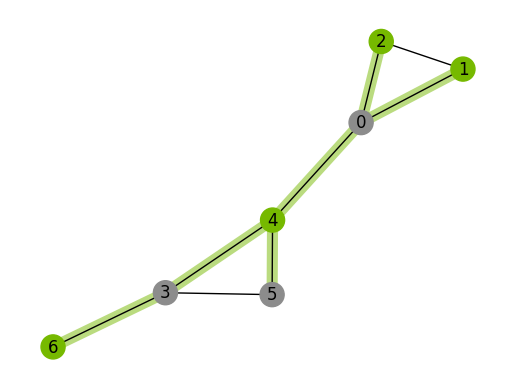

In [ ]:
for key in subGraph_dictionary:
    if key == 'sampleSubgraph0':
        graphColors=[1-int(i) for i in results[key]]
    else:
        graphColors=[int(i) for i in results[key]]

    nodes = sorted(list(nx.nodes(subGraph_dictionary[key])))

    for u in sampleGraph.nodes():
        if u in nodes:
            indexu = nodes.index(u)
            if graphColors[indexu] == 0:
                sampleGraph.nodes[u]['color']= 0
            else:
                sampleGraph.nodes[u]['color']= 1

cut_edges =[]
for u, v in sampleGraph.edges():
    if sampleGraph.nodes[u]['color']!= sampleGraph.nodes[v]['color']:
        cut_edges+=[(u,v)]

max_cut_color_map = [gray if sampleGraph.nodes[u]['color']==0 else green for u in sampleGraph]

nx.draw_networkx_edges(
    sampleGraph,
    pos,
    edgelist=cut_edges,
    width=8,
    alpha=0.5,
    edge_color=green,
)
nx.draw(sampleGraph, with_labels=True, pos = pos, node_color=max_cut_color_map)

plt.show()

In [ ]:
# Operator Gradient applet
scale = 0.8  # Change this to zoom: 0.7 = more zoomed out, 1.0 = full size
content_height = 1250  # Full height of the widget content in px
visible_height = int(content_height * scale)

HTML(f'''<div style="overflow:hidden; height:{visible_height}px;">
  <iframe src="https://nvidia.github.io/cuda-q-academic/interactive_widgets/operator-gradient.html"
    style="width:{int(100/scale)}%; height:{content_height}px; border:none;
           transform:scale({scale}); transform-origin:top left;">
  </iframe>
</div>''')

In [ ]:
# ADAPT-QAOA vs. Standard QAOA applet
scale = 0.8  # Change this to zoom: 0.7 = more zoomed out, 1.0 = full size
content_height = 2350  # Full height of the widget content in px
visible_height = int(content_height * scale)

HTML(f'''<div style="overflow:hidden; height:{visible_height}px;">
  <iframe src="https://nvidia.github.io/cuda-q-academic/interactive_widgets/adapt-qaoa.html"
    style="width:{int(100/scale)}%; height:{content_height}px; border:none;
           transform:scale({scale}); transform-origin:top left;">
  </iframe>
</div>''')

In [ ]:
@cudaq.kernel
def kernel_p1_plus_operator(qubits_num: int,
                             ham_word: list[cudaq.pauli_word],
                             ham_coef: list[complex],
                             base_params: list[float],
                             extra_op: list[cudaq.pauli_word],
                             extra_theta: float):
    qubits = cudaq.qvector(qubits_num)
    h(qubits)
    # Fixed QAOA layer 1 (same as kernel_qaoa_p1 with the optimized params)
    for i in range(len(ham_coef)):
        exp_pauli(base_params[0] * ham_coef[i].real, qubits, ham_word[i])
    for j in range(qubits_num):
        rx(2.0 * base_params[1], qubits[j])
    # One additional operator — this is what you're choosing
    exp_pauli(extra_theta, qubits, extra_op[0])

In [ ]:
cudaq.set_target('qpp-cpu')

candidate_operators = [
    ('XIIIIII', 'X₀  (single-qubit)'),
    ('IIIXIII', 'X₃  (single-qubit)'),
    ('IIIIIIX', 'X₆  (single-qubit)'),
    ('YYIIIII', 'Y₀Y₁  (edge 0–1)'),
    ('IIIYYII', 'Y₃Y₄  (edge 3–4)'),
    ('IIIIYYI', 'Y₄Y₅  (edge 4–5)'),
    ('IIIZIIY', 'Z₃Y₆  (edge 3–6)'),
    # YOUR OPERATORS HERE — try adding more candidates!
]

eps = 0.005
base_params = list(opt_params_p1)

base_cost = cudaq.observe(
    kernel_p1_plus_operator, H_hw, n_q,
    ham_word_hw, ham_coef_hw, base_params, ['IIIIIII'], 0.0
).expectation()

print(f"QAOA p=1 baseline cost: {base_cost:.4f}  (optimal = -{max_cut_value})")
print(f"\n{'Operator':<28} {'Gradient':>10}  {'|Gradient|':>10}")
print('=' * 52)

gradient_results = []
for pauli_str, label in candidate_operators:
    E_plus = cudaq.observe(
        kernel_p1_plus_operator, H_hw, n_q,
        ham_word_hw, ham_coef_hw, base_params, [pauli_str], eps
    ).expectation()

    E_minus = cudaq.observe(
        kernel_p1_plus_operator, H_hw, n_q,
        ham_word_hw, ham_coef_hw, base_params, [pauli_str], -eps
    ).expectation()

    grad = (E_plus - E_minus) / (2 * eps)
    gradient_results.append((pauli_str, label, grad))
    print(f"  {label:<26} {grad:>+10.4f}  {abs(grad):>10.4f}")

best_op_str, best_op_label, best_grad = max(gradient_results, key=lambda x: abs(x[2]))
print(f"\n→ Steepest gradient: {best_op_label}  (gradient = {best_grad:+.4f})")

QAOA p=1 baseline cost: -3.9436  (optimal = -6)

Operator                       Gradient  |Gradient|
  X₀  (single-qubit)            -0.4778      0.4778
  X₃  (single-qubit)            +0.0701      0.0701
  X₆  (single-qubit)            +0.1060      0.1060
  Y₀Y₁  (edge 0–1)              +0.1260      0.1260
  Y₃Y₄  (edge 3–4)              -1.1487      1.1487
  Y₄Y₅  (edge 4–5)              -0.0017      0.0017
  Z₃Y₆  (edge 3–6)              -0.7951      0.7951

→ Steepest gradient: Y₃Y₄  (edge 3–4)  (gradient = -1.1487)


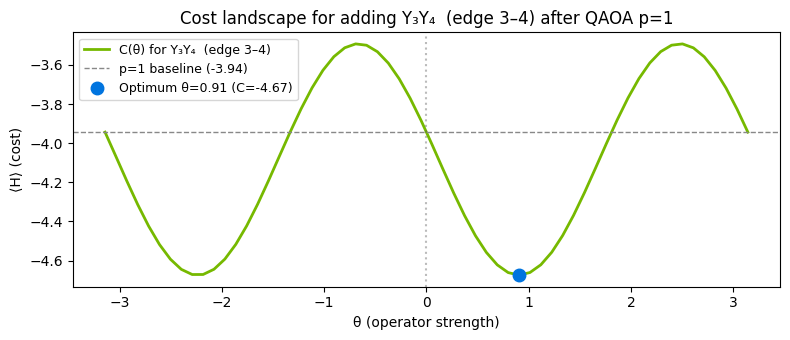

Optimized θ = 0.9052
Cost: -3.9436 → -4.6743  (ΔC = -0.7307)
Most probable bitstring: 0111101  (cut = 5 / 6)


In [ ]:
thetas_scan = np.linspace(-np.pi, np.pi, 60)
costs_scan = []
for t in thetas_scan:
    e = cudaq.observe(
        kernel_p1_plus_operator, H_hw, n_q,
        ham_word_hw, ham_coef_hw, base_params, [best_op_str], t
    ).expectation()
    costs_scan.append(e)

opt_idx = np.argmin(costs_scan)
opt_extra_theta = thetas_scan[opt_idx]
opt_cost = costs_scan[opt_idx]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(thetas_scan, costs_scan, color='#76b900', linewidth=2,
        label=f'C(θ) for {best_op_label}')
ax.axhline(base_cost, color='#888', linestyle='--', linewidth=1,
           label=f'p=1 baseline ({base_cost:.2f})')
ax.axvline(0, color='#555', linestyle=':', alpha=0.4)
ax.plot(opt_extra_theta, opt_cost, 'o', color='#0074df', markersize=9,
        zorder=5, label=f'Optimum θ={opt_extra_theta:.2f} (C={opt_cost:.2f})')
ax.set_xlabel('θ (operator strength)')
ax.set_ylabel('⟨H⟩ (cost)')
ax.set_title(f'Cost landscape for adding {best_op_label} after QAOA p=1')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

counts_extended_sim = cudaq.sample(
    kernel_p1_plus_operator, n_q,
    ham_word_hw, ham_coef_hw, base_params, [best_op_str], opt_extra_theta,
    shots_count=5000
)

ext_bs = counts_extended_sim.most_probable()
ext_cut = cut_value_from_bitstring(ext_bs)

print(f"Optimized θ = {opt_extra_theta:.4f}")
print(f"Cost: {base_cost:.4f} → {opt_cost:.4f}  (ΔC = {opt_cost - base_cost:+.4f})")
print(f"Most probable bitstring: {ext_bs}  (cut = {ext_cut} / {max_cut_value})")

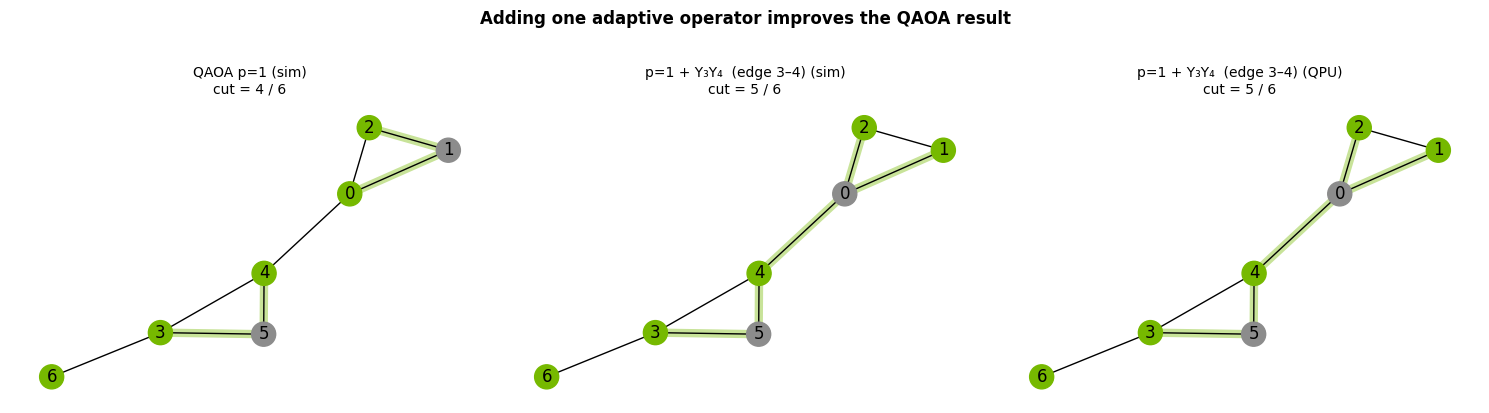


Summary:
  QAOA p=1 baseline:       cut = 4 / 6  (cost = -3.94)
  p=1 + Y₃Y₄  (edge 3–4):  cut = 5 / 6  (cost = -4.67)
  Adapt-QAOA (4 layers):   cut = 6 / 6  (cost = -6.00, pre-computed)


In [ ]:
# ══ QPU execution (uncomment when you have an IQM token) ═════════════════
# cudaq.set_target('iqm', url=iqm_url)
# counts_ext_qpu = cudaq.sample(
#     kernel_p1_plus_operator, n_q,
#     ham_word_hw, ham_coef_hw, base_params, [best_op_str], opt_extra_theta,
#     shots_count=5000
# )
# ext_qpu_bs = counts_ext_qpu.most_probable()[::-1]  # IQM qubit ordering
# ext_qpu_cut = cut_value_from_bitstring(ext_qpu_bs)
# print(f"Extended circuit (QPU): {ext_qpu_bs}  (cut = {ext_qpu_cut} / {max_cut_value})")

# ══ Side-by-side comparison ══════════════════════════════════════════════
cudaq.set_target('qpp-cpu')

counts_p1_ref = cudaq.sample(
    kernel_qaoa_p1, n_q, ham_word_hw, ham_coef_hw,
    list(opt_params_p1), 1, shots_count=5000
)
p1_ref_bs = counts_p1_ref.most_probable()
p1_ref_cut = cut_value_from_bitstring(p1_ref_bs)

ext_hw_bs = ext_bs  # ← replace with ext_qpu_bs when running on the QPU

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

titles = [
    f'QAOA p=1 (sim)\ncut = {p1_ref_cut} / {max_cut_value}',
    f'p=1 + {best_op_label} (sim)\ncut = {ext_cut} / {max_cut_value}',
    f'p=1 + {best_op_label} (QPU)\ncut = {cut_value_from_bitstring(ext_hw_bs)} / {max_cut_value}'
]
bitstrings = [p1_ref_bs, ext_bs, ext_hw_bs]

for ax, title, bs in zip(axes, titles, bitstrings):
    colors = [gray if int(bs[node_idx_hw[u]]) == 0 else green
              for u in sampleGraph]
    ce = [(u, v) for u, v in sampleGraph.edges()
          if bs[node_idx_hw[u]] != bs[node_idx_hw[v]]]
    nx.draw_networkx_edges(sampleGraph, pos, edgelist=ce,
                           width=6, alpha=0.4, edge_color=green, ax=ax)
    nx.draw(sampleGraph, with_labels=True, pos=pos,
            node_color=colors, ax=ax)
    ax.set_title(title, fontsize=10)

plt.suptitle('Adding one adaptive operator improves the QAOA result',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  QAOA p=1 baseline:       cut = {p1_ref_cut} / {max_cut_value}  "
      f"(cost = {base_cost:.2f})")
print(f"  p=1 + {best_op_label}:  cut = {ext_cut} / {max_cut_value}  "
      f"(cost = {opt_cost:.2f})")
print(f"  Adapt-QAOA (4 layers):   cut = {max_cut_value} / {max_cut_value}  "
      f"(cost = -6.00, pre-computed)")